In [1]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns

In [2]:
ds = sns.load_dataset('titanic')

In [3]:
ds

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,0,2,male,27.0,0,0,13.0000,S,Second,man,True,NaN,Southampton,no,True
887,1,1,female,19.0,0,0,30.0000,S,First,woman,False,B,Southampton,yes,True
888,0,3,female,NaN,1,2,23.4500,S,Third,woman,False,NaN,Southampton,no,False
889,1,1,male,26.0,0,0,30.0000,C,First,man,True,C,Cherbourg,yes,True


# Feature Transformation
* hundling missing values
* hundling catagorical feature [encoding]
* outliear detection
* feature scalling 

# hundling missing values 
* how to drop the missing values and which factors are depend to execute the drop process 

In [4]:
ds.isnull().sum()

survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64

# showing the missing values in percentage

In [5]:
ds.isnull().mean()*100

survived        0.000000
pclass          0.000000
sex             0.000000
age            19.865320
sibsp           0.000000
parch           0.000000
fare            0.000000
embarked        0.224467
class           0.000000
who             0.000000
adult_male      0.000000
deck           77.216611
embark_town     0.224467
alive           0.000000
alone           0.000000
dtype: float64

In [6]:
(ds.isnull().sum() / len(ds) * 100 )

survived        0.000000
pclass          0.000000
sex             0.000000
age            19.865320
sibsp           0.000000
parch           0.000000
fare            0.000000
embarked        0.224467
class           0.000000
who             0.000000
adult_male      0.000000
deck           77.216611
embark_town     0.224467
alive           0.000000
alone           0.000000
dtype: float64

In [7]:
ds.columns

Index(['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare',
       'embarked', 'class', 'who', 'adult_male', 'deck', 'embark_town',
       'alive', 'alone'],
      dtype='object')

# Condition for drop the missing valeus 
1. missing values is less then 5% then you will drop the  missing valeus
2. data should be distribute normally if you drop the missing valeus
3. atrandom :- data is not in continous sequence
* atrandom is also called the cca [complete case anylises] , mca [missing completely atrandom]

# Creating a plot for anylises how much data is distribute  

<Axes: ylabel='Density'>

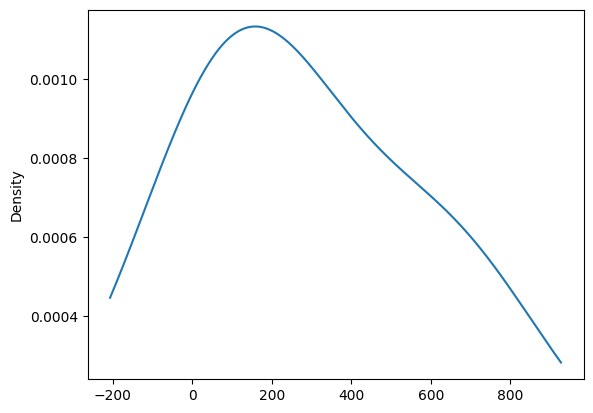

In [11]:
ds['embarked'].value_counts().plot(kind = 'kde' )

In [9]:
ds = ds.dropna(subset=['embarked'])

In [13]:
ds.isnull().sum()

survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         0
class            0
who              0
adult_male       0
deck           688
embark_town      0
alive            0
alone            0
dtype: int64

<Axes: ylabel='Density'>

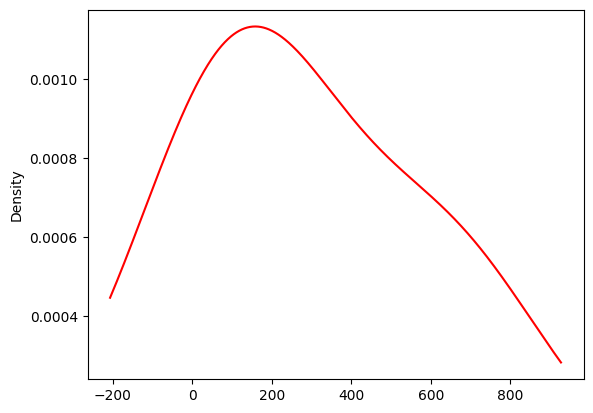

In [19]:
ds['embarked'].value_counts().plot(kind = 'kde' , color = 'red')

# ploting both graph before removing the missing valuse and after removing the missing values 

<Axes: ylabel='Density'>

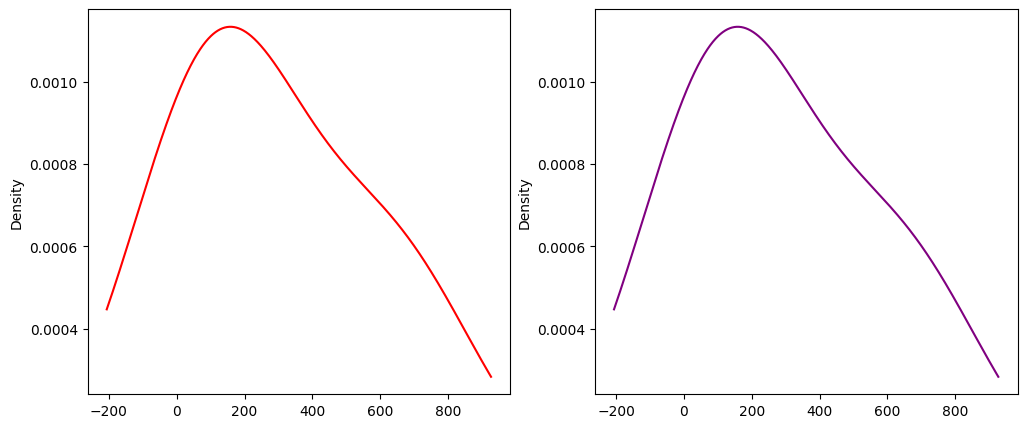

In [27]:
plt.figure(figsize= (12,5))
plt.subplot(1,2,1)
ds['embarked'].value_counts().plot(kind = 'kde' , color  ='red')
plt.subplot(1,2,2)
ds['embarked'].value_counts().plot(kind = 'kde', color = 'purple')

* so you can see in the above graph both graph showing  having a some data distribution data 
* that's mean i drop the data without facing any issue or problem  

# filling the missing values in numerical 

In [2]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer

In [17]:
dt = sns.load_dataset('titanic')
dt

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,0,2,male,27.0,0,0,13.0000,S,Second,man,True,NaN,Southampton,no,True
887,1,1,female,19.0,0,0,30.0000,S,First,woman,False,B,Southampton,yes,True
888,0,3,female,NaN,1,2,23.4500,S,Third,woman,False,NaN,Southampton,no,False
889,1,1,male,26.0,0,0,30.0000,C,First,man,True,C,Cherbourg,yes,True


In [31]:
dt = dt[['age','fare']]
dt.isnull().mean()*100

age     19.86532
fare     0.00000
dtype: float64

In [5]:
# dataset['age'].fillna(dataset['age']).mean()

In [6]:
age_mean = dt['age'].mean()
age_median = dt['age'].mean()

# adding new columns that showing the mean and median 

In [33]:
dt['new_mean'] = dt['age'].fillna(age_mean)
dt['new_median'] = dt['age'].fillna(age_median)

/var/folders/gd/yqc_8r1d50d5ldy5vyd_5lvm0000gn/T/ipykernel_33745/584891298.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dt['new_mean'] = dt['age'].fillna(age_mean)
/var/folders/gd/yqc_8r1d50d5ldy5vyd_5lvm0000gn/T/ipykernel_33745/584891298.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dt['new_median'] = dt['age'].fillna(age_median)


In [34]:
ds.head(10)

,age,fare
0,22.0,7.2500
1,38.0,71.2833
2,26.0,7.9250
3,35.0,53.1000
4,35.0,8.0500
5,NaN,8.4583
6,54.0,51.8625
7,2.0,21.0750
8,27.0,11.1333
9,14.0,30.0708


In [35]:
dt['age'].var()


211.0191247463081

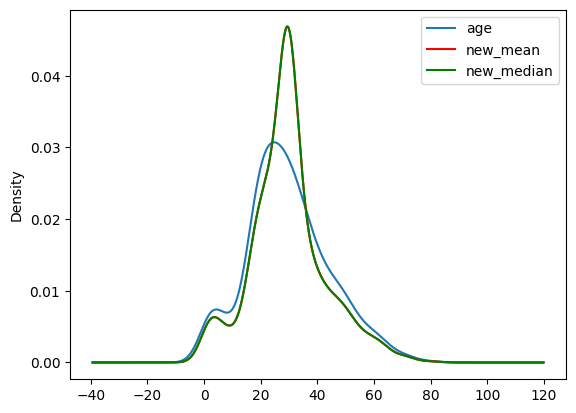

In [36]:
fig = plt.figure()
a = fig.add_subplot(111)
dt['age'].plot(kind = 'kde', ax = a)

dt['new_mean'].plot(kind = 'kde',ax = a, color = 'red')

dt['new_median'].plot(kind = 'kde',ax = a, color = 'green')
plt.legend()
plt.show()

<Axes: >

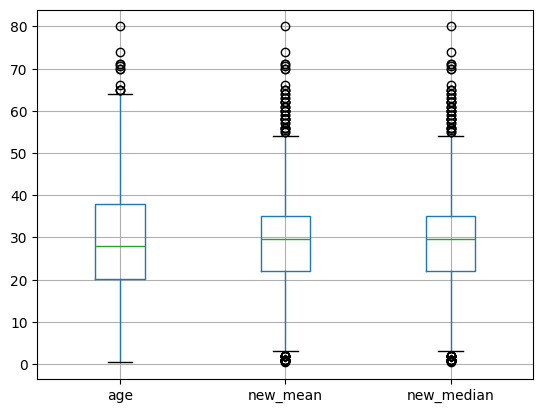

In [37]:
dt[["age","new_mean","new_median"]].boxplot()

In [30]:
# filling missing value with mode 

In [39]:
da = dt[['age','fare']]
da

,age,fare
0,22.0,7.2500
1,38.0,71.2833
2,26.0,7.9250
3,35.0,53.1000
4,35.0,8.0500
...,...,...
886,27.0,13.0000
887,19.0,30.0000
888,NaN,23.4500
889,26.0,30.0000


In [43]:
da_agemode = da['age'].mode()[0]
da['age_mode'] = da['age'].fillna(da_agemode)
da.sample(5) # pick random value 

/var/folders/gd/yqc_8r1d50d5ldy5vyd_5lvm0000gn/T/ipykernel_33745/1756807256.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  da['age_mode'] = da['age'].fillna(da_agemode)


,age,fare,age_mode
719,33.0,7.7750,33.0
295,NaN,27.7208,24.0
595,36.0,24.1500,36.0
748,19.0,53.1000,19.0
752,33.0,9.5000,33.0


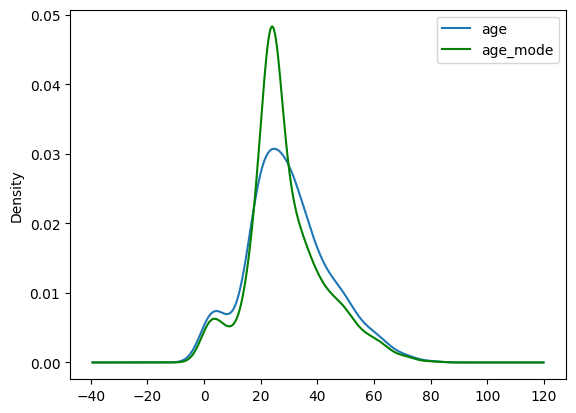

In [46]:
fig = plt.figure()
a = fig.add_subplot(111)
dt['age'].plot(kind = 'kde', ax = a)

# dt['new_mean'].plot(kind = 'kde',ax = a, color = 'red')

da['age_mode'].plot(kind = 'kde',ax = a, color = 'green')
plt.legend()
plt.show()

In [44]:
# if mean,median and mode not working (not change in the data )then using constant vlaue to fill the missing value 